Solver succeeded.


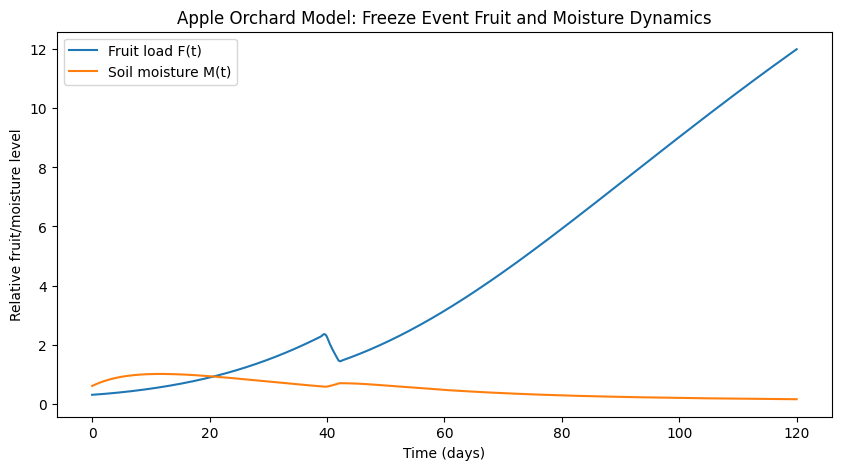

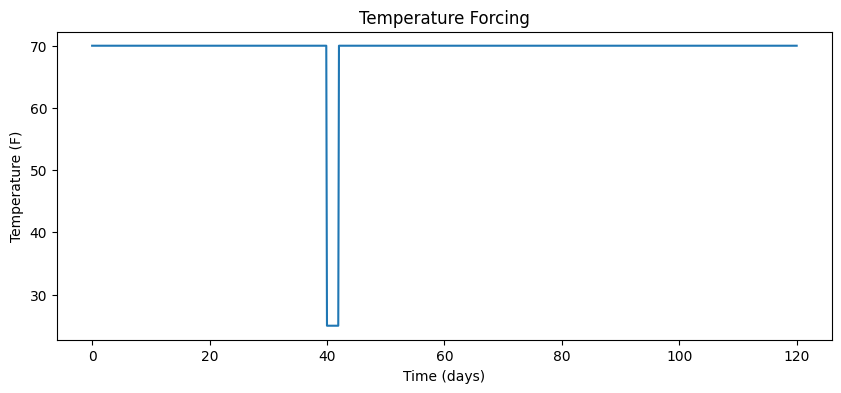

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================
# 1. PARAMETERS
# =========================

params = {
    # Fruit equation parameters
    "r": 0.10,        # baseline fruit growth rate
    "K_M": 0.40,      # moisture half-saturation constant
    "alpha": 0.04,    # pest damage strength
    "beta": 0.03,     # labor shortage damage strength
    "K_L": 0.50,      # labor half-penalty level
    "gamma": 0.08,    # freeze damage strength

    # Moisture equation parameters
    "a": 0.10,        # crop uptake coefficient
    "b": 0.002,       # temperature-driven drying coefficient
    "c": 0.003,        # baseline drainage/loss coefficient

    # Temperature thresholds
    "T_min": 55.0,    # lower bound of favorable growth range (F)
    "T_max": 85.0,    # upper bound of favorable growth range (F)
    "T_f": 28.0,      # freeze threshold (F)

    # Temperature penalty slopes
    "m1": 0.01,       # penalty slope below T_min
    "m2": 0.01        # penalty slope above T_max
}

# =========================
# 2. EXTERNAL INPUTS
# =========================
# These can be constants or functions of time.
# For now, I define simple baseline versions that you can edit later.

def T_func(t):
    """
    Temperature as a function of time.
    Baseline: constant 70 F, with an optional freeze event around day 40-42.
    """
    if 40 <= t <= 42:
        return 25.0   # freeze event
    return 70.0

def R_func(t):
    """Rainfall input."""
    return 0.1

def I_func(t):
    """Irrigation input."""
    return 0.1

def L_func(t):
    """Labor availability (scaled 0 to 1)."""
    return 0.80

def P_func(t):
    """Pest pressure (scaled 0 to 1)."""
    return 0.10

# =========================
# 3. HELPER FUNCTIONS
# =========================

def moisture_support(M, K_M):
    """
    Saturating normalized moisture effect:
        phi(M) = M / (K_M + M)
    """
    return M / (K_M + M)

def labor_penalty(L, K_L):
    """
    Labor shortage penalty:
        l(L) = K_L / (K_L + L)
    High when labor is low, small when labor is high.
    """
    return K_L / (K_L + L)

def temp_support(T, T_min, T_max, m1, m2):
    """
    Favorable temperature support psi(T):
    - equals 1 inside [T_min, T_max]
    - decreases linearly outside that range
    - clipped below at 0
    """
    if T < T_min:
        val = 1 - m1 * (T_min - T)
    elif T <= T_max:
        val = 1.0
    else:
        val = 1 - m2 * (T - T_max)

    return max(val, 0.0)

def freeze_penalty(T, T_f):
    """
    Freeze penalty s(T):
    - 0 if T >= T_f
    - T_f - T if T < T_f
    """
    if T >= T_f:
        return 0.0
    return T_f - T

# =========================
# 4. SYSTEM OF ODES
# =========================

def orchard_system(t, y, params):
    """
    y[0] = F(t): fruit load / potential yield
    y[1] = M(t): soil moisture
    """
    F, M = y

    # Prevent negative values from causing weird behavior in simulation
    F = max(F, 0.0)
    M = max(M, 0.0)

    # Unpack parameters
    r = params["r"]
    K_M = params["K_M"]
    alpha = params["alpha"]
    beta = params["beta"]
    K_L = params["K_L"]
    gamma = params["gamma"]

    a = params["a"]
    b = params["b"]
    c = params["c"]

    T_min = params["T_min"]
    T_max = params["T_max"]
    T_f = params["T_f"]
    m1 = params["m1"]
    m2 = params["m2"]

    # External inputs
    T = T_func(t)
    R = R_func(t)
    I = I_func(t)
    L = L_func(t)
    P = P_func(t)

    # Helper function values
    phi_M = moisture_support(M, K_M)
    psi_T = temp_support(T, T_min, T_max, m1, m2)
    ell_L = labor_penalty(L, K_L)
    s_T = freeze_penalty(T, T_f)

    # ODEs
    dFdt = (
        r * phi_M * psi_T * F
        - alpha * P * F
        - beta * ell_L * F
        - gamma * s_T * F
    )

    dMdt = (
        R + I
        - a * F * M
        - b * T * M
        - c * M
    )

    return [dFdt, dMdt]

# =========================
# 5. INITIAL CONDITIONS
# =========================

F0 = 0.30   # initial fruit load
M0 = 0.60   # initial soil moisture
y0 = [F0, M0]

# Time interval (days)
t_span = (0, 120)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# =========================
# 6. SOLVE NUMERICALLY
# =========================

sol = solve_ivp(
    fun=lambda t, y: orchard_system(t, y, params),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method="RK45"
)

# Check if solver succeeded
if not sol.success:
    print("Solver failed:", sol.message)
else:
    print("Solver succeeded.")

# =========================
# 7. PLOT RESULTS
# =========================

plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label="Fruit load F(t)")
plt.plot(sol.t, sol.y[1], label="Soil moisture M(t)")
plt.xlabel("Time (days)")
plt.ylabel("Relative fruit/moisture level")
plt.title("Apple Orchard Model: Freeze Event Fruit and Moisture Dynamics")
plt.legend()
plt.grid(False)
plt.savefig('freeze event conditions.png')
plt.show()

# =========================
# 8. OPTIONAL: PLOT EXTERNAL TEMPERATURE
# =========================

T_vals = [T_func(t) for t in sol.t]

plt.figure(figsize=(10, 4))
plt.plot(sol.t, T_vals)
plt.xlabel("Time (days)")
plt.ylabel("Temperature (F)")
plt.title("Temperature Forcing")
plt.grid(False)
plt.show()

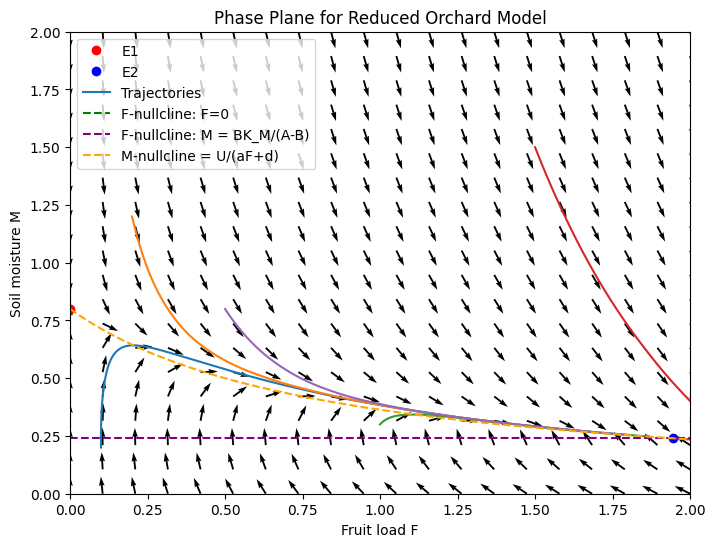

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ======================================
# PARAMETERS FOR REDUCED AUTONOMOUS MODEL
# ======================================
A = 0.08
B = 0.03
K_M = 0.40
U = 0.04
a = 0.06
d = 0.05

# ======================================
# REDUCED SYSTEM
# ======================================
def reduced_system(t, y):
    F, M = y
    dFdt = ((A * M / (K_M + M)) - B) * F
    dMdt = U - a * F * M - d * M
    return [dFdt, dMdt]

# ======================================
# VECTOR FIELD GRID
# ======================================
F_vals = np.linspace(0, 2.0, 20)
M_vals = np.linspace(0, 2.0, 20)

F_grid, M_grid = np.meshgrid(F_vals, M_vals)

dF = ((A * M_grid / (K_M + M_grid)) - B) * F_grid
dM = U - a * F_grid * M_grid - d * M_grid

# Normalize arrows so they don't get too huge
speed = np.sqrt(dF**2 + dM**2)
speed[speed == 0] = 1
dF_norm = dF / speed
dM_norm = dM / speed

# ======================================
# EQUILIBRIA
# ======================================
# E1
F1 = 0
M1 = U / d

# E2
M2 = (B * K_M) / (A - B)
F2 = (U * (A - B) - d * B * K_M) / (a * B * K_M)

# ======================================
# PLOT PHASE PLANE
# ======================================
plt.figure(figsize=(8, 6))
plt.quiver(F_grid, M_grid, dF_norm, dM_norm, angles='xy')

# Plot equilibrium points
plt.plot(F1, M1, 'ro', label='E1')
if F2 > 0 and M2 > 0:
    plt.plot(F2, M2, 'bo', label='E2')

# ======================================
# OPTIONAL: PLOT SOME TRAJECTORIES
# ======================================
initial_conditions = [
    [0.1, 0.2],
    [0.2, 1.2],
    [1.0, 0.3],
    [1.5, 1.5],
    [0.5, 0.8]
]

t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

for i, y0 in enumerate(initial_conditions):
    sol = solve_ivp(reduced_system, t_span, y0, t_eval=t_eval)
    
    if i == 0:
        plt.plot(sol.y[0], sol.y[1], linewidth=1.5, label='Trajectories')
    else:
        plt.plot(sol.y[0], sol.y[1], linewidth=1.5)

# ======================================
# NULLCLINES
# ======================================

# F-nullclines:
# 1) F = 0
plt.axvline(0, color='green', linestyle='--', label='F-nullcline: F=0')

# 2) A*M/(K_M+M) - B = 0  --> M = B*K_M/(A-B)
if A > B:
    M_null = (B * K_M) / (A - B)
    plt.axhline(M_null, color='purple', linestyle='--', label='F-nullcline: M = BK_M/(A-B)')

# M-nullcline:
# U - aFM - dM = 0  --> M = U / (aF + d)
F_curve = np.linspace(0, 2.0, 400)
M_curve = U / (a * F_curve + d)
plt.plot(F_curve, M_curve, color='orange', linestyle='--', label='M-nullcline = U/(aF+d)')

# ======================================
# LABELS
# ======================================
plt.xlabel("Fruit load F")
plt.ylabel("Soil moisture M")
plt.title("Phase Plane for Reduced Orchard Model")
plt.xlim(0, 2.0)
plt.ylim(0, 2.0)
plt.legend()
plt.grid(False)
plt.savefig('phaseplaneapple.png')
plt.show()